# 03 — Light-S: final training notebook

This notebook trains the **Light-S** saliency model:

- **encoder:** ImageNet-pretrained MobileNetV2;
- **input:** RGB image with shape `[B, 3, 169, 256]`;
- **output:** raw saliency logits with shape `[B, 1, 169, 256]`;
- **training objective:** KLD plus correlation loss;
- **checkpoint selection:** highest validation CC.

The notebook is intentionally compact. It keeps only the steps needed to:

1. prepare a fast local SALICON cache;
2. create the training and validation loaders;
3. verify the model/loss connection;
4. run a three-epoch pilot;
5. resume training to at most 15 total epochs;
6. monitor overfitting with training and validation curves;
7. load and evaluate the best checkpoint.

The internal test split is not used here.

## Execution notes

Use a **GPU runtime** in Google Colab.

Persistent files remain in Google Drive:

- original SALICON data;
- `best.pt` and `last.pt`;
- epoch-history CSV;
- training curves;
- fixed validation predictions;
- validation metrics.

Training reads images and maps from `/content/saliency_cache/SALICON`, not directly from Drive.

The first execution may create one uncompressed archive in Drive. That one-time operation can be slow because every original dataset file must be read once. In later sessions, Colab copies and extracts one archive, which is much faster than opening thousands of Drive files during every epoch.

The notebook automatically resumes from `checkpoints/light_single/last.pt` when it already exists.

## 1. Mount Drive, clone or update the repository, and define paths

In [1]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import shutil
import subprocess
import sys


# ---------------------------------------------------------------------
# Stable project locations
# ---------------------------------------------------------------------
REPO_URL = "https://github.com/RicoDalB/efficient-saliency-prediction.git"
REPO_ROOT = Path("/content/efficient-saliency-prediction")

DRIVE_ROOT = Path("/content/drive/MyDrive/saliency_project")
DRIVE_DATA_ROOT = DRIVE_ROOT / "data" / "SALICON"

TRAIN_MANIFEST_PATH = REPO_ROOT / "splits" / "train_manifest.csv"
VAL_MANIFEST_PATH = REPO_ROOT / "splits" / "val_manifest.csv"


# ---------------------------------------------------------------------
# Clone the repository in a fresh runtime or pull the newest main branch.
# The repository under /content is temporary; GitHub remains the source
# of the Python code and notebook.
# ---------------------------------------------------------------------
if not REPO_ROOT.exists():
    subprocess.run(
        ["git", "clone", REPO_URL, str(REPO_ROOT)],
        check=True,
    )
else:
    pull_result = subprocess.run(
        [
            "git",
            "-C",
            str(REPO_ROOT),
            "pull",
            "--ff-only",
            "origin",
            "main",
        ],
        capture_output=True,
        text=True,
    )

    print(pull_result.stdout)

    if pull_result.returncode != 0:
        print(pull_result.stderr)
        raise RuntimeError(
            "Git pull failed. The temporary Colab clone may contain "
            "uncommitted changes. Restart the runtime or clean the clone."
        )


# Make the repository importable as a Python project.
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


# ---------------------------------------------------------------------
# Verify the files needed by this notebook.
# ---------------------------------------------------------------------
required_paths = [
    REPO_ROOT / "src" / "data.py",
    REPO_ROOT / "src" / "losses_metrics.py",
    REPO_ROOT / "src" / "models.py",
    REPO_ROOT / "src" / "train_eval.py",
    TRAIN_MANIFEST_PATH,
    VAL_MANIFEST_PATH,
    DRIVE_DATA_ROOT / "images",
    DRIVE_DATA_ROOT / "maps",
]

for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(f"Required project path not found: {path}")


print("Repository:          ", REPO_ROOT)
print("Drive SALICON root:  ", DRIVE_DATA_ROOT)
print("Training manifest:   ", TRAIN_MANIFEST_PATH)
print("Validation manifest: ", VAL_MANIFEST_PATH)

Mounted at /content/drive
Repository:           /content/efficient-saliency-prediction
Drive SALICON root:   /content/drive/MyDrive/saliency_project/data/SALICON
Training manifest:    /content/efficient-saliency-prediction/splits/train_manifest.csv
Validation manifest:  /content/efficient-saliency-prediction/splits/val_manifest.csv


## 2. Imports, reproducibility, and training configuration

In [2]:
import importlib
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch


# Reload project modules after the Git pull so Colab does not use an
# older cached version from a previous import.
import src.data
import src.losses_metrics
import src.models
import src.train_eval

importlib.invalidate_caches()
importlib.reload(src.data)
importlib.reload(src.losses_metrics)
importlib.reload(src.models)
importlib.reload(src.train_eval)

from src.data import SaliconDataset, build_dataloader
from src.losses_metrics import (
    saliency_loss,
    spatial_softmax,
    validate_spatial_distribution,
)
from src.models import build_model, parameter_summary
from src.train_eval import (
    build_optimizer,
    evaluate_and_save,
    fit_model,
    load_checkpoint,
    plot_training_history,
)


# ---------------------------------------------------------------------
# Fail early when the GitHub version of train_eval.py is incomplete.
# ---------------------------------------------------------------------
required_training_functions = [
    "build_optimizer",
    "evaluate_and_save",
    "fit_model",
    "load_checkpoint",
    "plot_training_history",
]

missing_training_functions = [
    name
    for name in required_training_functions
    if not hasattr(src.train_eval, name)
]

if missing_training_functions:
    raise ImportError(
        "src/train_eval.py is incomplete. Missing functions: "
        f"{missing_training_functions}. Push the complete file to GitHub, "
        "then rerun this notebook from the beginning."
    )


# ---------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


# ---------------------------------------------------------------------
# Main experiment settings
# ---------------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_NAME = "light_single"
OUTPUT_SIZE = (169, 256)       # (height, width)
DECODER_CHANNELS = 32

BATCH_SIZE = 8
NUM_WORKERS = 2

PILOT_EPOCHS = 3
MAX_EPOCHS = 15
EARLY_STOPPING_PATIENCE = 3

ENCODER_LR = 1e-4
DECODER_LR = 3e-4
WEIGHT_DECAY = 1e-4
GRADIENT_CLIP_NORM = 1.0


if DEVICE.type != "cuda":
    raise RuntimeError(
        "A CUDA GPU is required for practical training time. "
        "In Colab select Runtime > Change runtime type > GPU."
    )


print("Device:       ", DEVICE)
print("PyTorch:      ", torch.__version__)
print("CUDA:         ", torch.version.cuda)
print("GPU:          ", torch.cuda.get_device_name(0))
print("Output size:  ", OUTPUT_SIZE)
print("Batch size:   ", BATCH_SIZE)
print("Data workers: ", NUM_WORKERS)

Device:        cuda
PyTorch:       2.11.0+cu128
CUDA:          12.8
GPU:           Tesla T4
Output size:   (169, 256)
Batch size:    8
Data workers:  2


## 3. Prepare the fast local SALICON cache

Repeatedly opening images and maps from mounted Google Drive is slow. This cell uses a two-level strategy:

```text
Google Drive
└── backups/salicon_images_maps.tar       persistent archive

/content
└── saliency_cache/SALICON/               fast temporary training copy
    ├── images/
    └── maps/
```

Behaviour:

- when the local cache already exists, it is reused;
- when the Drive archive exists, one file is copied and extracted;
- when the archive does not exist, it is created once from `images/` and `maps/`, saved to Drive, and extracted locally;
- incomplete local caches are removed and rebuilt safely.

Fixation files are not copied because this experiment trains and evaluates against continuous saliency maps.

In [3]:
# ---------------------------------------------------------------------
# Persistent and temporary cache paths
# ---------------------------------------------------------------------
#
# IMPORTANT DESIGN:
#
# - Google Drive remains the permanent source of truth.
# - The Colab local disk is used for fast training reads.
# - On the first execution, files are copied from Drive to the local cache.
# - Only after the local copy is verified do we create one persistent TAR.
# - The TAR is built FROM LOCAL FILES and written sequentially to Drive.
#
# This avoids the unreliable operation that previously tried to make GNU tar
# read thousands of files directly through the mounted Drive filesystem.
# ---------------------------------------------------------------------

from pathlib import Path
import os
import shutil
import subprocess
import time


SALICON_ARCHIVE_DRIVE = (
    DRIVE_ROOT
    / "backups"
    / "salicon_images_maps.tar"
)

TEMPORARY_DRIVE_ARCHIVE = Path(
    str(SALICON_ARCHIVE_DRIVE) + ".tmp"
)

LOCAL_CACHE_ROOT = Path("/content/saliency_cache")
LOCAL_DATA_ROOT = LOCAL_CACHE_ROOT / "SALICON"
LOCAL_ARCHIVE_PATH = Path("/content/salicon_images_maps.tar")
CACHE_READY_MARKER = LOCAL_DATA_ROOT / ".cache_ready"

DRIVE_IMAGE_ROOT = DRIVE_DATA_ROOT / "images"
DRIVE_MAP_ROOT = DRIVE_DATA_ROOT / "maps"

LOCAL_IMAGE_ROOT = LOCAL_DATA_ROOT / "images"
LOCAL_MAP_ROOT = LOCAL_DATA_ROOT / "maps"

SALICON_ARCHIVE_DRIVE.parent.mkdir(
    parents=True,
    exist_ok=True,
)


def print_local_disk_space() -> None:
    """
    Print total, used, and free space on the temporary Colab disk.

    The local cache disappears when the Colab runtime is deleted, so this
    space is temporary and separate from Google Drive storage.
    """
    total, used, free = shutil.disk_usage("/content")

    print(f"Local disk total: {total / (1024 ** 3):.2f} GB")
    print(f"Local disk used:  {used / (1024 ** 3):.2f} GB")
    print(f"Local disk free:  {free / (1024 ** 3):.2f} GB")


def local_cache_is_valid() -> bool:
    """
    Return True only when the cache marker and both required folders exist.

    The marker is created only after the image and map copies have been
    verified. Its presence prevents unnecessary repeated copying inside the
    same Colab runtime.
    """
    return (
        CACHE_READY_MARKER.is_file()
        and LOCAL_IMAGE_ROOT.is_dir()
        and LOCAL_MAP_ROOT.is_dir()
    )


def list_regular_files(root: Path) -> list[Path]:
    """
    Return every regular file found recursively below ``root``.

    Parameters
    ----------
    root:
        Directory whose contents must be enumerated.

    Returns
    -------
    list[Path]
        Sorted list of all regular files below ``root``.

    Raises
    ------
    FileNotFoundError
        If the source directory does not exist.
    RuntimeError
        If the source directory contains no files.
    """
    if not root.is_dir():
        raise FileNotFoundError(
            f"Required source folder does not exist: {root}"
        )

    files = sorted(
        path
        for path in root.rglob("*")
        if path.is_file()
    )

    if not files:
        raise RuntimeError(
            f"No files were found under: {root}"
        )

    return files


def copy_file_with_retries(
    source: Path,
    destination: Path,
    *,
    maximum_attempts: int = 3,
) -> None:
    """
    Copy one file from Drive to local disk, retrying transient Drive errors.

    Parameters
    ----------
    source:
        Original file in the mounted Google Drive dataset.

    destination:
        Corresponding file inside the temporary local SALICON cache.

    maximum_attempts:
        Maximum number of copy attempts before the error is raised.

    Returns
    -------
    None
        The function creates or replaces ``destination``.
    """
    destination.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    last_error = None

    for attempt in range(1, maximum_attempts + 1):
        try:
            shutil.copy2(source, destination)
            return

        except OSError as error:
            last_error = error

            if attempt < maximum_attempts:
                wait_seconds = attempt * 2

                print(
                    f"\nTemporary copy error for {source.name}. "
                    f"Retrying in {wait_seconds} seconds..."
                )

                time.sleep(wait_seconds)

    raise RuntimeError(
        f"Could not copy {source} after "
        f"{maximum_attempts} attempts."
    ) from last_error


def copy_tree_to_local_cache(
    source_root: Path,
    destination_root: Path,
    *,
    label: str,
    progress_interval: int = 250,
) -> tuple[int, int]:
    """
    Copy one complete directory tree from Drive to the local Colab disk.

    Existing destination files with the same byte size are skipped. This makes
    the operation resumable when a previous copy was interrupted.

    Parameters
    ----------
    source_root:
        Root directory on mounted Google Drive.

    destination_root:
        Matching root directory inside ``/content/saliency_cache``.

    label:
        Human-readable label displayed in progress messages.

    progress_interval:
        Print one progress update after this many processed files.

    Returns
    -------
    tuple[int, int]
        ``(number_of_files, total_number_of_bytes)`` in the verified source
        tree.
    """
    source_files = list_regular_files(source_root)

    total_files = len(source_files)
    total_bytes = sum(
        path.stat().st_size
        for path in source_files
    )

    destination_root.mkdir(
        parents=True,
        exist_ok=True,
    )

    print(
        f"\n{label}: {total_files:,} files, "
        f"{total_bytes / (1024 ** 3):.2f} GB"
    )

    copied_files = 0
    skipped_files = 0
    started_at = time.perf_counter()

    for index, source_path in enumerate(source_files, start=1):
        relative_path = source_path.relative_to(source_root)
        destination_path = destination_root / relative_path

        source_size = source_path.stat().st_size

        if (
            destination_path.is_file()
            and destination_path.stat().st_size == source_size
        ):
            skipped_files += 1

        else:
            copy_file_with_retries(
                source_path,
                destination_path,
            )
            copied_files += 1

        if (
            index == 1
            or index % progress_interval == 0
            or index == total_files
        ):
            elapsed = time.perf_counter() - started_at
            rate = index / max(elapsed, 1e-6)

            print(
                f"\r{label}: {index:,}/{total_files:,} files "
                f"processed | copied {copied_files:,} | "
                f"reused {skipped_files:,} | "
                f"{rate:.1f} files/s",
                end="",
                flush=True,
            )

    print()

    # Verify every destination file using its relative path and byte size.
    missing_or_incomplete = []

    for source_path in source_files:
        relative_path = source_path.relative_to(source_root)
        destination_path = destination_root / relative_path

        if (
            not destination_path.is_file()
            or destination_path.stat().st_size
            != source_path.stat().st_size
        ):
            missing_or_incomplete.append(
                relative_path.as_posix()
            )

            if len(missing_or_incomplete) >= 10:
                break

    if missing_or_incomplete:
        raise RuntimeError(
            f"{label} local copy verification failed. "
            f"Examples: {missing_or_incomplete}"
        )

    print(f"{label} local copy verified successfully.")

    return total_files, total_bytes


def create_persistent_archive_from_local_cache() -> None:
    """
    Create the persistent SALICON TAR from the verified local cache.

    The TAR reads only from the local Colab disk and writes one sequential file
    to Drive. This is more reliable than asking GNU tar to read thousands of
    files directly from the mounted Drive filesystem.

    The archive is first written with a ``.tmp`` suffix and renamed only after
    successful completion, so an interrupted write is never mistaken for a
    valid archive.
    """
    if TEMPORARY_DRIVE_ARCHIVE.exists():
        TEMPORARY_DRIVE_ARCHIVE.unlink()

    print("\nCreating the persistent TAR from the verified local cache...")
    print("The source is now local; Drive receives only one sequential file.")

    command = [
        "tar",
        "-cf",
        str(TEMPORARY_DRIVE_ARCHIVE),
        "-C",
        str(LOCAL_CACHE_ROOT),
        "SALICON/images",
        "SALICON/maps",
    ]

    result = subprocess.run(
        command,
        capture_output=True,
        text=True,
    )

    if result.returncode != 0:
        if TEMPORARY_DRIVE_ARCHIVE.exists():
            TEMPORARY_DRIVE_ARCHIVE.unlink()

        raise RuntimeError(
            "Persistent TAR creation failed.\n\n"
            f"Command: {' '.join(command)}\n\n"
            f"STDOUT:\n{result.stdout}\n\n"
            f"STDERR:\n{result.stderr}"
        )

    if (
        not TEMPORARY_DRIVE_ARCHIVE.is_file()
        or TEMPORARY_DRIVE_ARCHIVE.stat().st_size == 0
    ):
        raise RuntimeError(
            "The temporary persistent archive is missing or empty."
        )

    if SALICON_ARCHIVE_DRIVE.exists():
        SALICON_ARCHIVE_DRIVE.unlink()

    TEMPORARY_DRIVE_ARCHIVE.replace(
        SALICON_ARCHIVE_DRIVE
    )

    archive_size_gb = (
        SALICON_ARCHIVE_DRIVE.stat().st_size
        / (1024 ** 3)
    )

    print(
        f"Persistent archive saved successfully: "
        f"{archive_size_gb:.2f} GB"
    )
    print(SALICON_ARCHIVE_DRIVE)


def extract_existing_persistent_archive() -> None:
    """
    Copy an existing persistent TAR to local disk and extract it.

    This is the normal path in future Colab runtimes after the one-time archive
    has already been created.

    Returns
    -------
    None
        The function creates ``LOCAL_DATA_ROOT`` and the readiness marker.
    """
    archive_size_gb = (
        SALICON_ARCHIVE_DRIVE.stat().st_size
        / (1024 ** 3)
    )

    print("\nPersistent SALICON archive found in Drive.")
    print(f"Archive size: {archive_size_gb:.2f} GB")
    print("Copying the single archive to the local Colab disk...")

    if LOCAL_ARCHIVE_PATH.exists():
        LOCAL_ARCHIVE_PATH.unlink()

    shutil.copy2(
        SALICON_ARCHIVE_DRIVE,
        LOCAL_ARCHIVE_PATH,
    )

    if LOCAL_CACHE_ROOT.exists():
        shutil.rmtree(LOCAL_CACHE_ROOT)

    LOCAL_CACHE_ROOT.mkdir(
        parents=True,
        exist_ok=True,
    )

    print("Extracting SALICON into the local cache...")

    command = [
        "tar",
        "-xf",
        str(LOCAL_ARCHIVE_PATH),
        "-C",
        str(LOCAL_CACHE_ROOT),
    ]

    result = subprocess.run(
        command,
        capture_output=True,
        text=True,
    )

    if result.returncode != 0:
        raise RuntimeError(
            "SALICON extraction failed.\n\n"
            f"STDOUT:\n{result.stdout}\n\n"
            f"STDERR:\n{result.stderr}"
        )

    if not LOCAL_IMAGE_ROOT.is_dir():
        raise RuntimeError(
            "The extracted image folder was not found."
        )

    if not LOCAL_MAP_ROOT.is_dir():
        raise RuntimeError(
            "The extracted map folder was not found."
        )

    CACHE_READY_MARKER.touch()

    # The copied TAR is no longer needed after successful extraction.
    LOCAL_ARCHIVE_PATH.unlink()

    print("Local SALICON cache extracted and verified successfully.")


# ---------------------------------------------------------------------
# Main cache workflow
# ---------------------------------------------------------------------

print_local_disk_space()

# Remove the incomplete local TAR produced by the previous failed method.
if LOCAL_ARCHIVE_PATH.exists():
    print("\nRemoving an incomplete local TAR from the failed attempt...")
    LOCAL_ARCHIVE_PATH.unlink()


if local_cache_is_valid():
    print("\nLocal SALICON cache is already ready.")

elif SALICON_ARCHIVE_DRIVE.is_file():
    extract_existing_persistent_archive()

else:
    print("\nNo persistent archive was found.")
    print("Preparing the one-time local cache directly from Drive...")
    print(
        "This operation reads every image and map once, "
        "but it prints progress and can reuse completed files."
    )

    LOCAL_DATA_ROOT.mkdir(
        parents=True,
        exist_ok=True,
    )

    CACHE_READY_MARKER.unlink(
        missing_ok=True,
    )

    image_file_count, image_bytes = copy_tree_to_local_cache(
        DRIVE_IMAGE_ROOT,
        LOCAL_IMAGE_ROOT,
        label="Images",
    )

    map_file_count, map_bytes = copy_tree_to_local_cache(
        DRIVE_MAP_ROOT,
        LOCAL_MAP_ROOT,
        label="Maps",
    )

    total_dataset_bytes = image_bytes + map_bytes

    print(
        f"\nVerified local dataset: "
        f"{image_file_count + map_file_count:,} files, "
        f"{total_dataset_bytes / (1024 ** 3):.2f} GB"
    )

    # Mark the cache as ready before TAR creation. If the Drive TAR write is
    # interrupted, the current runtime can still train from the verified cache.
    CACHE_READY_MARKER.touch()

    create_persistent_archive_from_local_cache()


if not local_cache_is_valid():
    raise RuntimeError(
        "The local SALICON cache did not pass final validation."
    )


TRAINING_DATA_ROOT = LOCAL_DATA_ROOT

print("\nTraining data root:", TRAINING_DATA_ROOT)
print_local_disk_space()

Local disk total: 112.64 GB
Local disk used:  46.75 GB
Local disk free:  65.87 GB

No persistent archive was found.
Preparing the one-time local cache directly from Drive...
This operation reads every image and map once, but it prints progress and can reuse completed files.

Images: 20,000 files, 2.12 GB
Images: 20,000/20,000 files processed | copied 20,000 | reused 0 | 3.2 files/s
Images local copy verified successfully.

Maps: 15,000 files, 0.42 GB
Maps: 15,000/15,000 files processed | copied 15,000 | reused 0 | 6.7 files/s
Maps local copy verified successfully.

Verified local dataset: 35,000 files, 2.54 GB

Creating the persistent TAR from the verified local cache...
The source is now local; Drive receives only one sequential file.
Persistent archive saved successfully: 2.57 GB
/content/drive/MyDrive/saliency_project/backups/salicon_images_maps.tar

Training data root: /content/saliency_cache/SALICON
Local disk total: 112.64 GB
Local disk used:  54.69 GB
Local disk free:  57.93 GB


## 4. Output paths, datasets, and DataLoaders

In [4]:
# ---------------------------------------------------------------------
# Persistent Light-S outputs
# ---------------------------------------------------------------------
LIGHT_SINGLE_CHECKPOINT_DIR = (
    DRIVE_ROOT
    / "checkpoints"
    / MODEL_NAME
)

LIGHT_SINGLE_HISTORY_PATH = (
    DRIVE_ROOT
    / "outputs"
    / "metrics"
    / "light_single_history.csv"
)

LIGHT_SINGLE_CURVES_PATH = (
    DRIVE_ROOT
    / "outputs"
    / "figures"
    / "training_curves_light_single.png"
)

LIGHT_SINGLE_PREVIEW_PATH = (
    DRIVE_ROOT
    / "outputs"
    / "figures"
    / "light_single_validation_predictions.png"
)

LIGHT_SINGLE_VAL_SUMMARY_PATH = (
    DRIVE_ROOT
    / "outputs"
    / "metrics"
    / "light_single_validation_metrics.csv"
)

LIGHT_SINGLE_VAL_PER_IMAGE_PATH = (
    DRIVE_ROOT
    / "outputs"
    / "metrics"
    / "light_single_validation_per_image.csv"
)


for directory in [
    LIGHT_SINGLE_CHECKPOINT_DIR,
    LIGHT_SINGLE_HISTORY_PATH.parent,
    LIGHT_SINGLE_CURVES_PATH.parent,
]:
    directory.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------------------
# Create temporary manifest copies that always contain paths relative to
# the SALICON root.
#
# This makes local caching work even when an older manifest accidentally
# stores absolute Google Drive paths or paths containing "data/SALICON".
# The original version-controlled manifests are never modified.
# ---------------------------------------------------------------------
LOCAL_MANIFEST_ROOT = Path("/content/local_salicon_manifests")
LOCAL_MANIFEST_ROOT.mkdir(parents=True, exist_ok=True)

LOCAL_TRAIN_MANIFEST_PATH = (
    LOCAL_MANIFEST_ROOT
    / "train_manifest.csv"
)

LOCAL_VAL_MANIFEST_PATH = (
    LOCAL_MANIFEST_ROOT
    / "val_manifest.csv"
)


def path_relative_to_salicon(path_value: object) -> str:
    """
    Convert one manifest path into a path relative to the SALICON root.

    Examples
    --------
    /content/drive/.../SALICON/images/example.jpg
        -> images/example.jpg

    data/SALICON/maps/train/example.png
        -> maps/train/example.png

    images/images/example.jpg
        -> images/images/example.jpg
    """
    path = Path(str(path_value))
    parts = path.parts

    if "SALICON" in parts:
        salicon_index = parts.index("SALICON")
        relative_parts = parts[salicon_index + 1 :]

        if not relative_parts:
            raise ValueError(
                f"Path does not identify a file below SALICON: {path}"
            )

        return str(Path(*relative_parts))

    if path.is_absolute():
        try:
            return str(path.relative_to(DRIVE_DATA_ROOT))
        except ValueError as error:
            raise ValueError(
                "Absolute manifest path is outside the configured "
                f"SALICON root: {path}"
            ) from error

    return str(path)


def create_local_manifest(
    source_path: Path,
    destination_path: Path,
) -> Path:
    """
    Create one temporary manifest whose image and map paths are relative.

    Parameters
    ----------
    source_path:
        Original frozen manifest stored in the GitHub repository.

    destination_path:
        Temporary CSV written under /content.

    Returns
    -------
    Path
        Path to the temporary localized manifest.
    """
    dataframe = pd.read_csv(source_path)

    required_columns = {
        "sample_id",
        "image_relpath",
        "map_relpath",
    }

    missing_columns = required_columns.difference(dataframe.columns)

    if missing_columns:
        raise ValueError(
            f"{source_path.name} is missing columns: "
            f"{sorted(missing_columns)}"
        )

    dataframe["image_relpath"] = dataframe["image_relpath"].map(
        path_relative_to_salicon
    )

    dataframe["map_relpath"] = dataframe["map_relpath"].map(
        path_relative_to_salicon
    )

    dataframe.to_csv(
        destination_path,
        index=False,
    )

    # Check all localized paths before a long training run begins.
    missing_examples = []

    for row in dataframe.itertuples(index=False):
        image_path = TRAINING_DATA_ROOT / row.image_relpath
        map_path = TRAINING_DATA_ROOT / row.map_relpath

        if not image_path.is_file() or not map_path.is_file():
            missing_examples.append(
                {
                    "sample_id": row.sample_id,
                    "image": str(image_path),
                    "map": str(map_path),
                }
            )

            if len(missing_examples) >= 5:
                break

    if missing_examples:
        raise FileNotFoundError(
            "Localized manifest paths do not match the local cache. "
            f"Examples: {missing_examples}"
        )

    return destination_path


create_local_manifest(
    TRAIN_MANIFEST_PATH,
    LOCAL_TRAIN_MANIFEST_PATH,
)

create_local_manifest(
    VAL_MANIFEST_PATH,
    LOCAL_VAL_MANIFEST_PATH,
)


# ---------------------------------------------------------------------
# Dataset objects now resolve paths under the local cache.
# ---------------------------------------------------------------------
train_dataset = SaliconDataset(
    manifest_path=LOCAL_TRAIN_MANIFEST_PATH,
    data_root=TRAINING_DATA_ROOT,
    image_column="image_relpath",
    map_column="map_relpath",
    id_column="sample_id",
    output_size=OUTPUT_SIZE,
    use_imagenet_normalization=True,
)

val_dataset = SaliconDataset(
    manifest_path=LOCAL_VAL_MANIFEST_PATH,
    data_root=TRAINING_DATA_ROOT,
    image_column="image_relpath",
    map_column="map_relpath",
    id_column="sample_id",
    output_size=OUTPUT_SIZE,
    use_imagenet_normalization=True,
)


train_loader = build_dataloader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    num_workers=NUM_WORKERS,
)

val_loader = build_dataloader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED,
    num_workers=NUM_WORKERS,
)


print("Localized train manifest: ", LOCAL_TRAIN_MANIFEST_PATH)
print("Localized val manifest:   ", LOCAL_VAL_MANIFEST_PATH)
print("Training samples:         ", len(train_dataset))
print("Validation samples:       ", len(val_dataset))
print("Training batches:         ", len(train_loader))
print("Validation batches:       ", len(val_loader))
print("Checkpoint folder:        ", LIGHT_SINGLE_CHECKPOINT_DIR)
print("History CSV:              ", LIGHT_SINGLE_HISTORY_PATH)

Localized train manifest:  /content/local_salicon_manifests/train_manifest.csv
Localized val manifest:    /content/local_salicon_manifests/val_manifest.csv
Training samples:          10000
Validation samples:        2500
Training batches:          1250
Validation batches:        313
Checkpoint folder:         /content/drive/MyDrive/saliency_project/checkpoints/light_single
History CSV:               /content/drive/MyDrive/saliency_project/outputs/metrics/light_single_history.csv


## 5. Verify local loading speed and keep a fixed validation preview

In [5]:
# ---------------------------------------------------------------------
# Measure several batches. The first batch includes worker startup, so the
# average over multiple batches is more informative than one isolated read.
# ---------------------------------------------------------------------
TIMING_BATCHES = min(20, len(train_loader))

loading_start = time.perf_counter()
timing_iterator = iter(train_loader)

for _ in range(TIMING_BATCHES):
    _ = next(timing_iterator)

loading_seconds = time.perf_counter() - loading_start

print(
    f"Loaded {TIMING_BATCHES} local batches in "
    f"{loading_seconds:.2f} seconds "
    f"({loading_seconds / TIMING_BATCHES:.3f} seconds per batch)."
)


# ---------------------------------------------------------------------
# Reuse the same four validation examples after every epoch.
# This makes qualitative progress and centre-collapse easier to detect.
# ---------------------------------------------------------------------
validation_batch = next(iter(val_loader))

preview_batch = {
    "image": validation_batch["image"][:4].clone(),
    "target": validation_batch["target"][:4].clone(),
    "sample_id": list(validation_batch["sample_id"][:4]),
}

validate_spatial_distribution(
    preview_batch["target"],
    name="preview_targets",
)

print("\nFixed validation preview IDs:")
for sample_id in preview_batch["sample_id"]:
    print(" -", sample_id)

Loaded 20 local batches in 2.76 seconds (0.138 seconds per batch).

Fixed validation preview IDs:
 - 1000
 - 100000
 - 100081
 - 100187


## 6. Pre-training sanity check

This single compact test replaces the longer architecture-debug section of the development notebook.

It verifies that:

- the model returns the correct output shape;
- logits become a valid spatial distribution;
- the saliency loss is finite;
- gradients reach both encoder and decoder.

The model used in this diagnostic cell is discarded. Real training starts from a fresh model in the next section.

In [6]:
sanity_model = build_model(
    MODEL_NAME,
    pretrained=True,
    decoder_channels=DECODER_CHANNELS,
).to(DEVICE)

sanity_summary = parameter_summary(sanity_model)

sanity_batch = next(iter(train_loader))
sanity_images = sanity_batch["image"].to(
    DEVICE,
    non_blocking=True,
)
sanity_targets = sanity_batch["target"].to(
    DEVICE,
    non_blocking=True,
)

sanity_model.train()
sanity_logits = sanity_model(sanity_images)
sanity_loss = saliency_loss(
    sanity_logits,
    sanity_targets,
)
sanity_prediction = spatial_softmax(sanity_logits)

validate_spatial_distribution(
    sanity_prediction,
    name="sanity_prediction",
)

sanity_model.zero_grad(set_to_none=True)
sanity_loss.backward()

encoder_has_gradient = any(
    parameter.grad is not None
    for parameter in sanity_model.encoder.parameters()
    if parameter.requires_grad
)

decoder_has_gradient = any(
    parameter.grad is not None
    for parameter in sanity_model.decoder.parameters()
    if parameter.requires_grad
)

assert sanity_logits.shape == sanity_targets.shape
assert torch.isfinite(sanity_loss)
assert encoder_has_gradient
assert decoder_has_gradient

print("Parameter summary:", sanity_summary)
print("Input shape:      ", tuple(sanity_images.shape))
print("Output shape:     ", tuple(sanity_logits.shape))
print("Finite loss:      ", float(sanity_loss.detach()))
print("Encoder gradient: ", encoder_has_gradient)
print("Decoder gradient: ", decoder_has_gradient)
print("\nPre-training sanity check passed.")


# Release diagnostic tensors and model before the real training run.
del (
    sanity_model,
    sanity_batch,
    sanity_images,
    sanity_targets,
    sanity_logits,
    sanity_loss,
    sanity_prediction,
)

torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 121MB/s]


Parameter summary: {'encoder': 1811712, 'decoder': 14401, 'total': 1826113, 'trainable': 1826113}
Input shape:       (8, 3, 169, 256)
Output shape:      (8, 1, 169, 256)
Finite loss:       1.790988802909851
Encoder gradient:  True
Decoder gradient:  True

Pre-training sanity check passed.


## 7. Experiment configuration and reusable model creation

The encoder receives a lower learning rate because it starts from ImageNet weights. The new decoder receives a higher learning rate.

The encoder is frozen during epoch 1, then unfrozen. Validation CC selects `best.pt`. Early stopping activates after three consecutive epochs without sufficient validation-CC improvement.

In [7]:
light_single_config = {
    "model_name": MODEL_NAME,
    "encoder_name": "MobileNetV2",
    "decoder_type": "single_scale",
    "pretrained_encoder": True,
    "decoder_channels": DECODER_CHANNELS,
    "output_height": OUTPUT_SIZE[0],
    "output_width": OUTPUT_SIZE[1],
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "optimizer": "AdamW",
    "encoder_learning_rate": ENCODER_LR,
    "decoder_learning_rate": DECODER_LR,
    "weight_decay": WEIGHT_DECAY,
    "gradient_clip_norm": GRADIENT_CLIP_NORM,
    "freeze_encoder_epochs": 1,
    "freeze_encoder_batchnorm": True,
    "automatic_mixed_precision": True,
    "checkpoint_metric": "validation_cc",
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "minimum_cc_improvement": 1e-4,
    "split_seed": SEED,
    "training_data_root": str(TRAINING_DATA_ROOT),
}


def create_light_single_experiment():
    """
    Create a fresh Light-S model and its two-learning-rate AdamW optimizer.

    Returns
    -------
    model:
        A new ImageNet-pretrained Light-S model on DEVICE.

    optimizer:
        AdamW with one parameter group for the encoder and another for
        the decoder.
    """
    model = build_model(
        MODEL_NAME,
        pretrained=True,
        decoder_channels=DECODER_CHANNELS,
    ).to(DEVICE)

    optimizer = build_optimizer(
        model,
        encoder_lr=ENCODER_LR,
        decoder_lr=DECODER_LR,
        weight_decay=WEIGHT_DECAY,
    )

    return model, optimizer


print("Experiment configuration:")
display(pd.DataFrame([light_single_config]).T.rename(columns={0: "value"}))

Experiment configuration:


,value
model_name,light_single
encoder_name,MobileNetV2
decoder_type,single_scale
pretrained_encoder,True
decoder_channels,32
output_height,169
output_width,256
batch_size,8
num_workers,2
optimizer,AdamW


## 8. Three-epoch pilot

The pilot uses the complete training and validation splits.

It verifies:

- local-cache throughput;
- GPU memory;
- epoch duration;
- checkpoint creation;
- CSV history;
- training and validation curves;
- fixed validation predictions.

When `last.pt` already exists, this cell resumes automatically. If that checkpoint has already completed at least three epochs, no epochs are repeated.


light_single | epoch 1/3 | encoder: frozen | AMP: True
Train loss: 0.7113 | Val loss: 0.5548 | Val KLD: 0.4253 | Val CC: 0.7417 | Val SIM: 0.6679
Epoch time: 2.54 min | Best val CC: 0.7417 | No-improvement counter: 0/3
New best checkpoint saved to: /content/drive/MyDrive/saliency_project/checkpoints/light_single/best.pt
Last checkpoint saved to: /content/drive/MyDrive/saliency_project/checkpoints/light_single/last.pt
History CSV updated at: /content/drive/MyDrive/saliency_project/outputs/metrics/light_single_history.csv


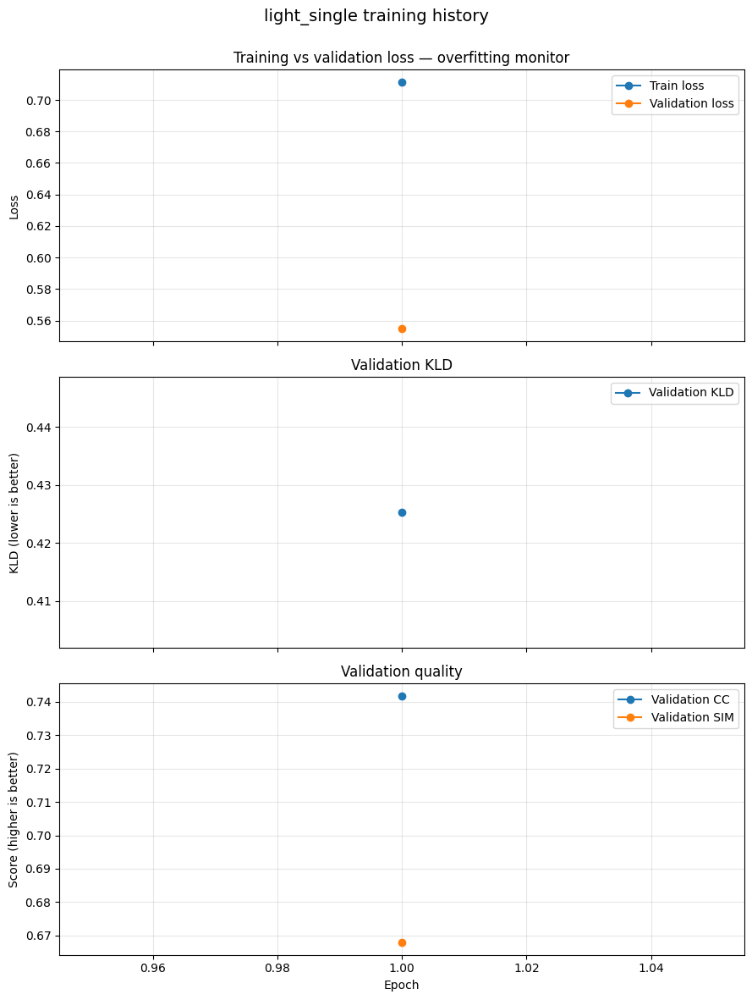

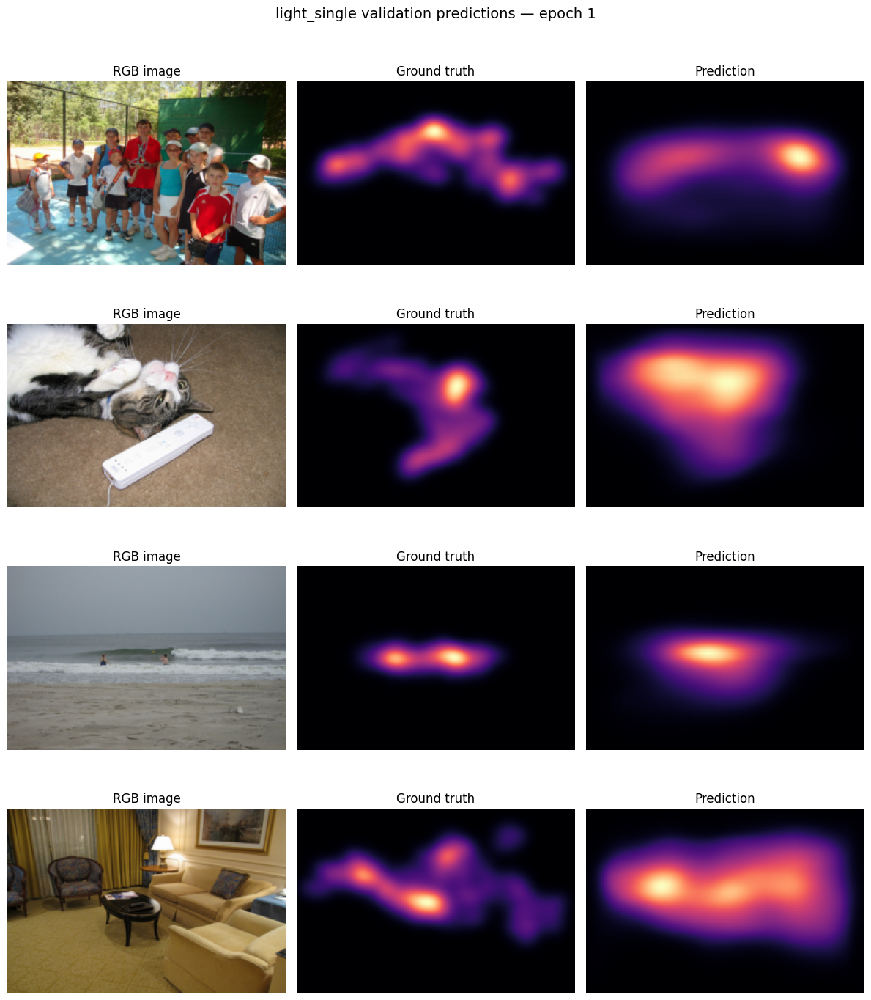


light_single | epoch 2/3 | encoder: trainable | AMP: True
Train loss: 0.4086 | Val loss: 0.3398 | Val KLD: 0.2666 | Val CC: 0.8542 | Val SIM: 0.7464
Epoch time: 2.44 min | Best val CC: 0.8542 | No-improvement counter: 0/3
New best checkpoint saved to: /content/drive/MyDrive/saliency_project/checkpoints/light_single/best.pt
Last checkpoint saved to: /content/drive/MyDrive/saliency_project/checkpoints/light_single/last.pt
History CSV updated at: /content/drive/MyDrive/saliency_project/outputs/metrics/light_single_history.csv


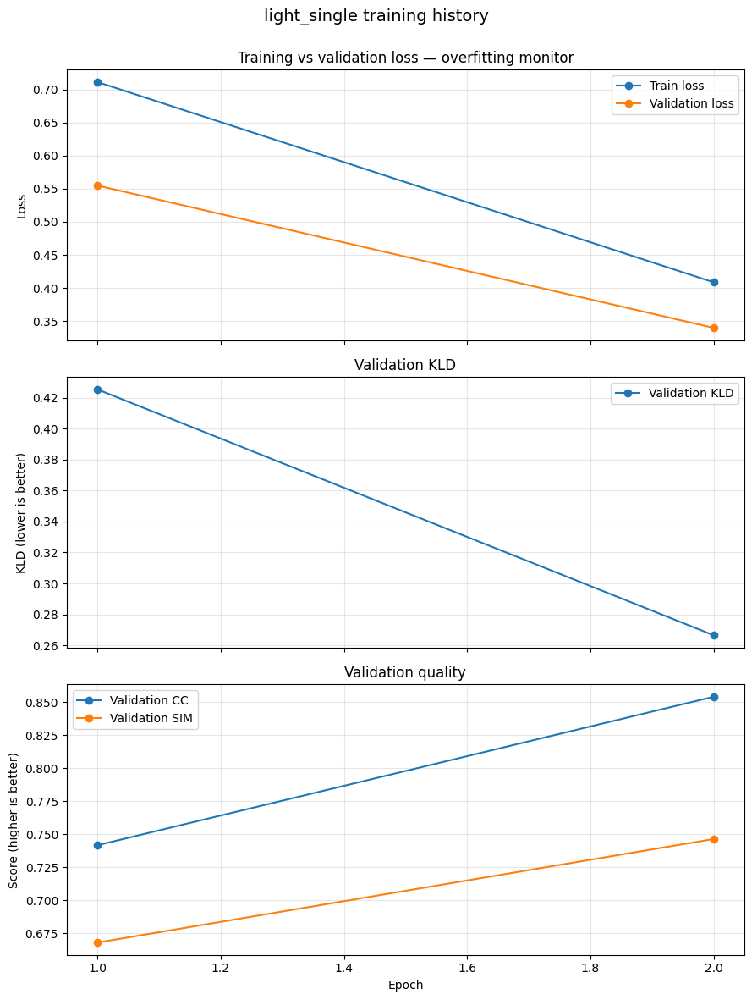

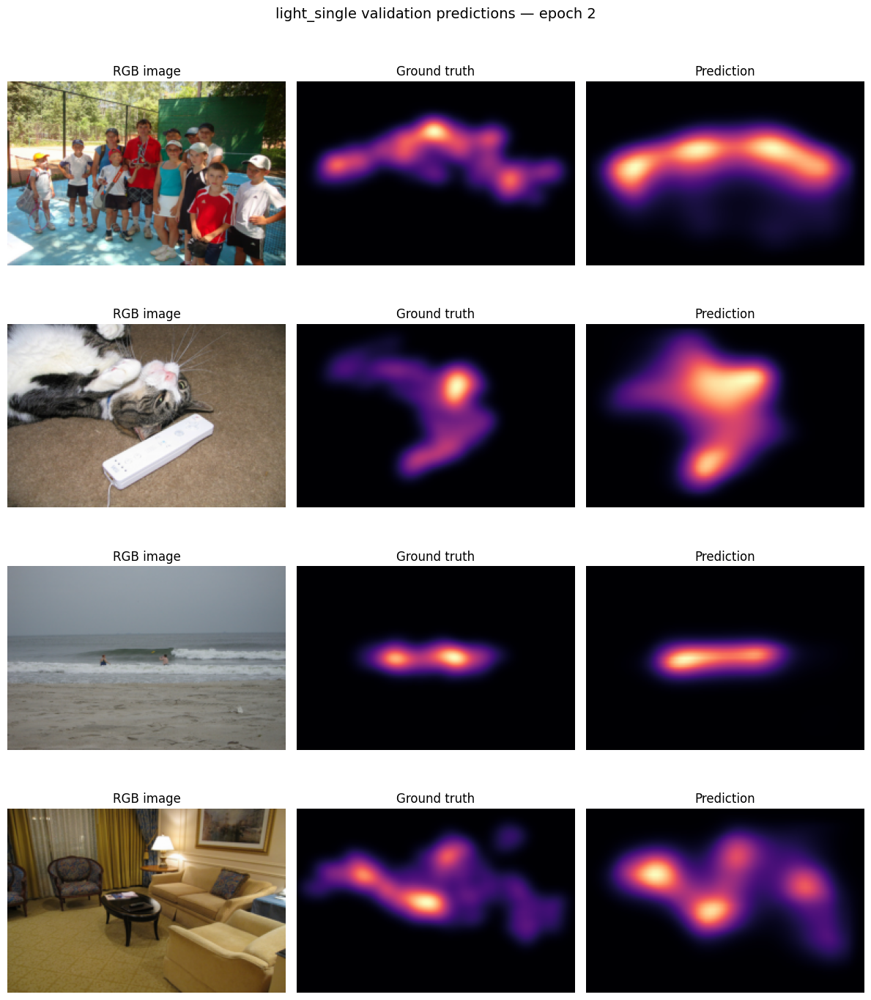


light_single | epoch 3/3 | encoder: trainable | AMP: True
Train loss: 0.3304 | Val loss: 0.3241 | Val KLD: 0.2531 | Val CC: 0.8590 | Val SIM: 0.7547
Epoch time: 2.36 min | Best val CC: 0.8590 | No-improvement counter: 0/3
New best checkpoint saved to: /content/drive/MyDrive/saliency_project/checkpoints/light_single/best.pt
Last checkpoint saved to: /content/drive/MyDrive/saliency_project/checkpoints/light_single/last.pt
History CSV updated at: /content/drive/MyDrive/saliency_project/outputs/metrics/light_single_history.csv


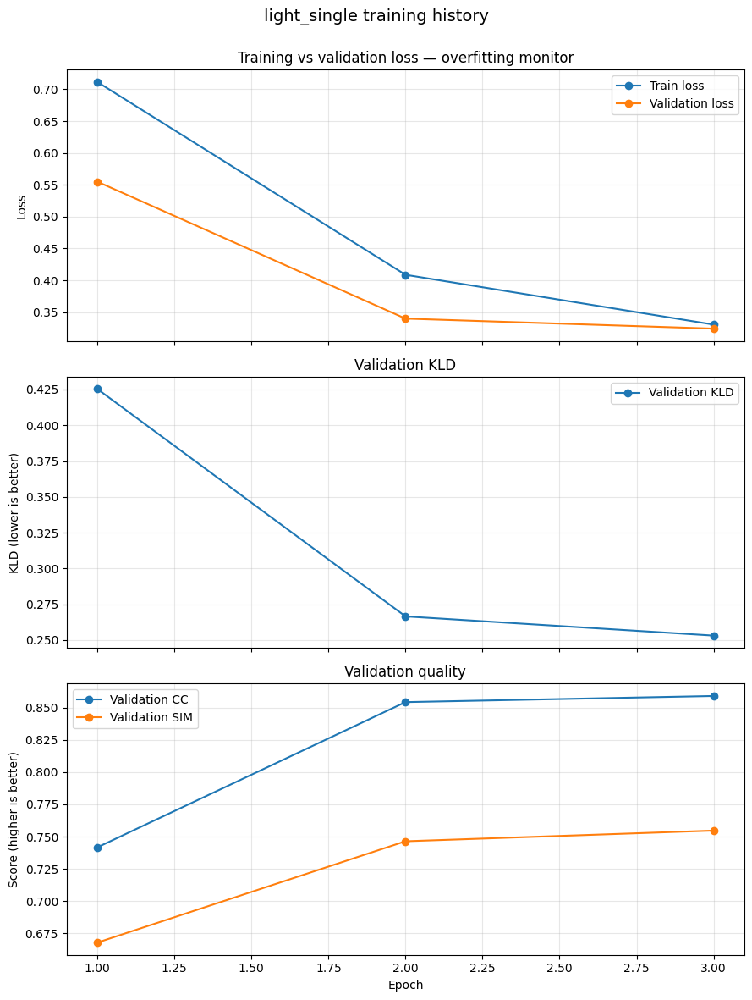

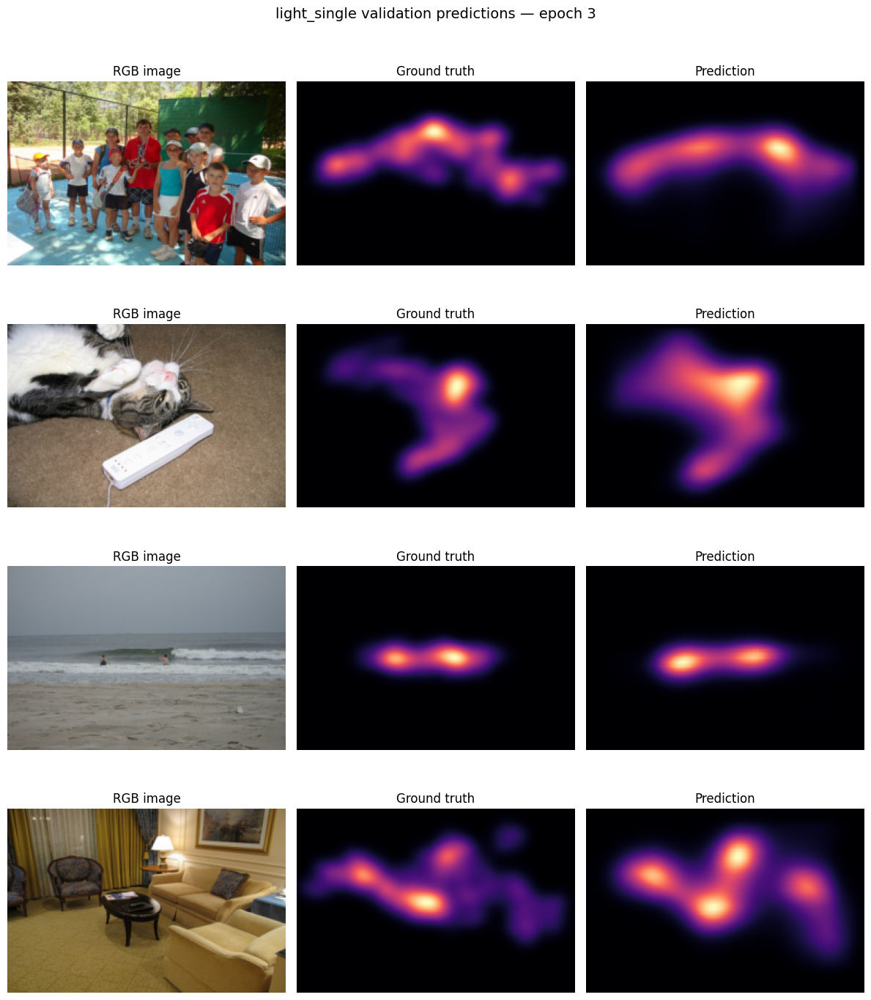


Training finished for light_single. Best validation CC: 0.8590. Elapsed time: 7.57 minutes.
Best checkpoint: /content/drive/MyDrive/saliency_project/checkpoints/light_single/best.pt
Last checkpoint: /content/drive/MyDrive/saliency_project/checkpoints/light_single/last.pt


,epoch,train_loss,val_loss,val_kld,val_cc,val_sim,encoder_trainable,epoch_time_seconds
0,1,0.711343,0.554842,0.425307,0.741707,0.667906,False,152.115096
1,2,0.408649,0.339826,0.266556,0.854228,0.746400,True,146.103652
2,3,0.330408,0.324076,0.253146,0.858973,0.754656,True,141.503598


Best checkpoint: True
Last checkpoint: True
History CSV:     True
Curves figure:   True
Preview figure:  True


In [8]:
LAST_CHECKPOINT_PATH = LIGHT_SINGLE_CHECKPOINT_DIR / "last.pt"
BEST_CHECKPOINT_PATH = LIGHT_SINGLE_CHECKPOINT_DIR / "best.pt"

pilot_model, pilot_optimizer = create_light_single_experiment()

pilot_resume_path = (
    LAST_CHECKPOINT_PATH
    if LAST_CHECKPOINT_PATH.is_file()
    else None
)

pilot_history = fit_model(
    model=pilot_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=pilot_optimizer,
    device=DEVICE,

    model_name=MODEL_NAME,
    epochs=PILOT_EPOCHS,

    checkpoint_dir=LIGHT_SINGLE_CHECKPOINT_DIR,
    history_csv_path=LIGHT_SINGLE_HISTORY_PATH,
    curves_figure_path=LIGHT_SINGLE_CURVES_PATH,

    preview_batch=preview_batch,
    preview_figure_path=LIGHT_SINGLE_PREVIEW_PATH,

    config=light_single_config,
    split_seed=SEED,
    repo_root=REPO_ROOT,

    patience=EARLY_STOPPING_PATIENCE,
    min_delta=1e-4,

    freeze_encoder_epochs=1,
    freeze_encoder_batchnorm=True,

    use_amp=True,
    gradient_clip_norm=GRADIENT_CLIP_NORM,

    resume_from=pilot_resume_path,
    show_curves_each_epoch=True,
)

pilot_history_frame = pd.DataFrame(pilot_history)

display(
    pilot_history_frame[
        [
            "epoch",
            "train_loss",
            "val_loss",
            "val_kld",
            "val_cc",
            "val_sim",
            "encoder_trainable",
            "epoch_time_seconds",
        ]
    ]
)

print("Best checkpoint:", BEST_CHECKPOINT_PATH.is_file())
print("Last checkpoint:", LAST_CHECKPOINT_PATH.is_file())
print("History CSV:    ", LIGHT_SINGLE_HISTORY_PATH.is_file())
print("Curves figure:  ", LIGHT_SINGLE_CURVES_PATH.is_file())
print("Preview figure: ", LIGHT_SINGLE_PREVIEW_PATH.is_file())


# Release the pilot model before recreating it from the checkpoint.
del pilot_model, pilot_optimizer
torch.cuda.empty_cache()

## 9. Resume the final Light-S run

This cell restores `last.pt` and continues to a maximum of 15 **total** epochs, not 15 additional epochs.

Training may finish earlier through validation-CC early stopping. The reportable model is always `best.pt`, even when `last.pt` belongs to a later epoch.

Resumed light_single from epoch 3. Next epoch: 4; best validation CC: 0.8590.

light_single | epoch 4/15 | encoder: trainable | AMP: True
Train loss: 0.2932 | Val loss: 0.3008 | Val KLD: 0.2370 | Val CC: 0.8732 | Val SIM: 0.7635
Epoch time: 2.42 min | Best val CC: 0.8732 | No-improvement counter: 0/3
New best checkpoint saved to: /content/drive/MyDrive/saliency_project/checkpoints/light_single/best.pt
Last checkpoint saved to: /content/drive/MyDrive/saliency_project/checkpoints/light_single/last.pt
History CSV updated at: /content/drive/MyDrive/saliency_project/outputs/metrics/light_single_history.csv


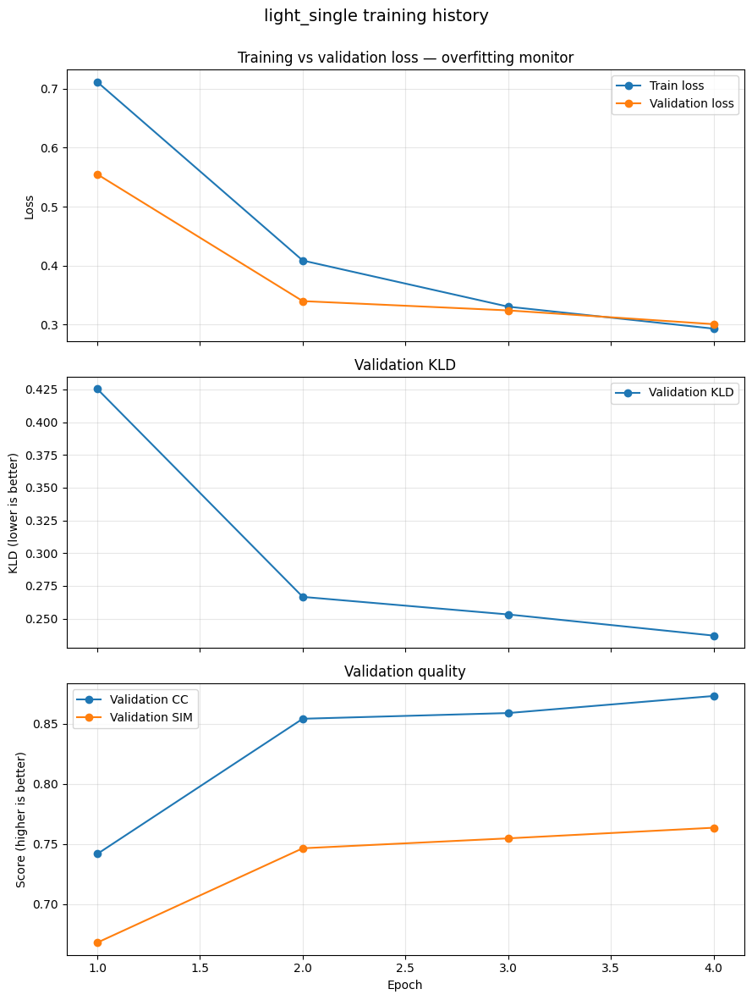

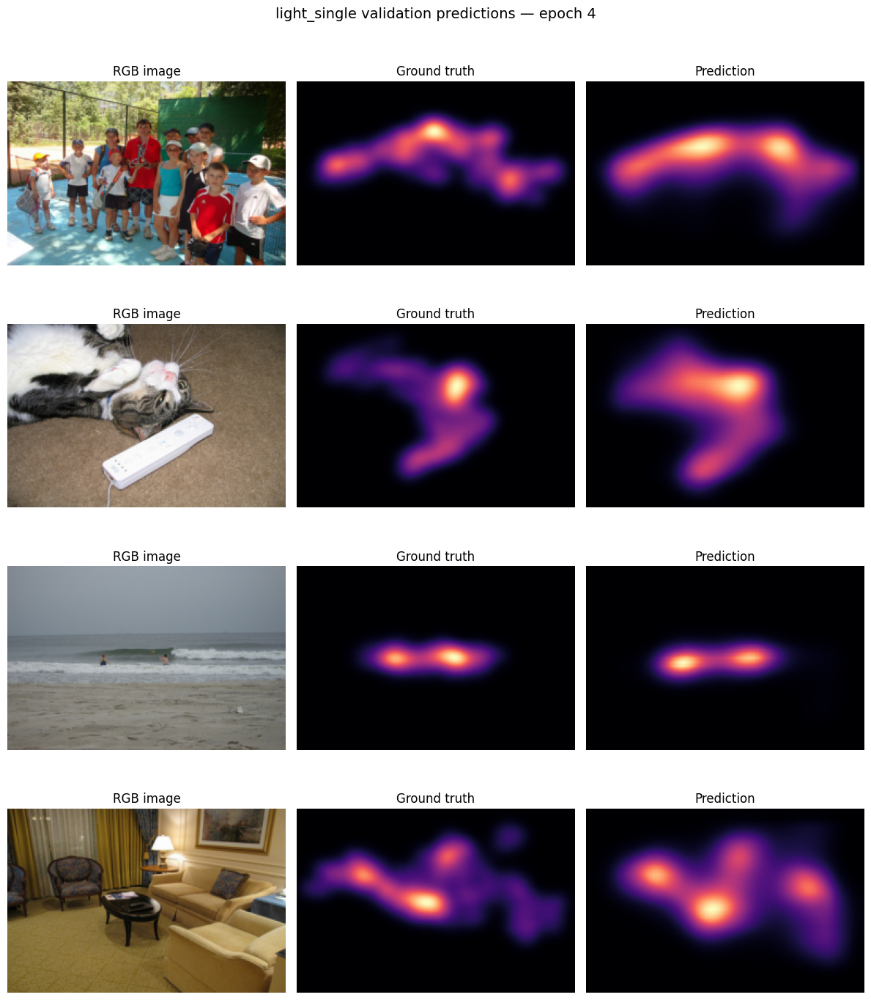


light_single | epoch 5/15 | encoder: trainable | AMP: True
Train loss: 0.2648 | Val loss: 0.2988 | Val KLD: 0.2353 | Val CC: 0.8739 | Val SIM: 0.7692
Epoch time: 2.41 min | Best val CC: 0.8739 | No-improvement counter: 0/3
New best checkpoint saved to: /content/drive/MyDrive/saliency_project/checkpoints/light_single/best.pt
Last checkpoint saved to: /content/drive/MyDrive/saliency_project/checkpoints/light_single/last.pt
History CSV updated at: /content/drive/MyDrive/saliency_project/outputs/metrics/light_single_history.csv


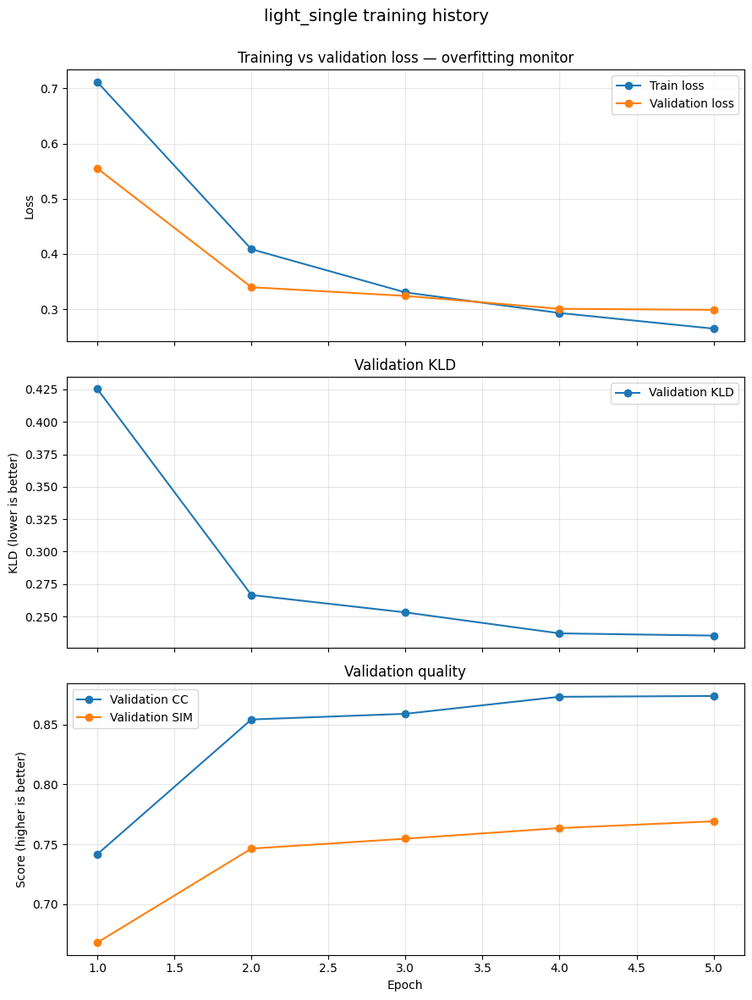

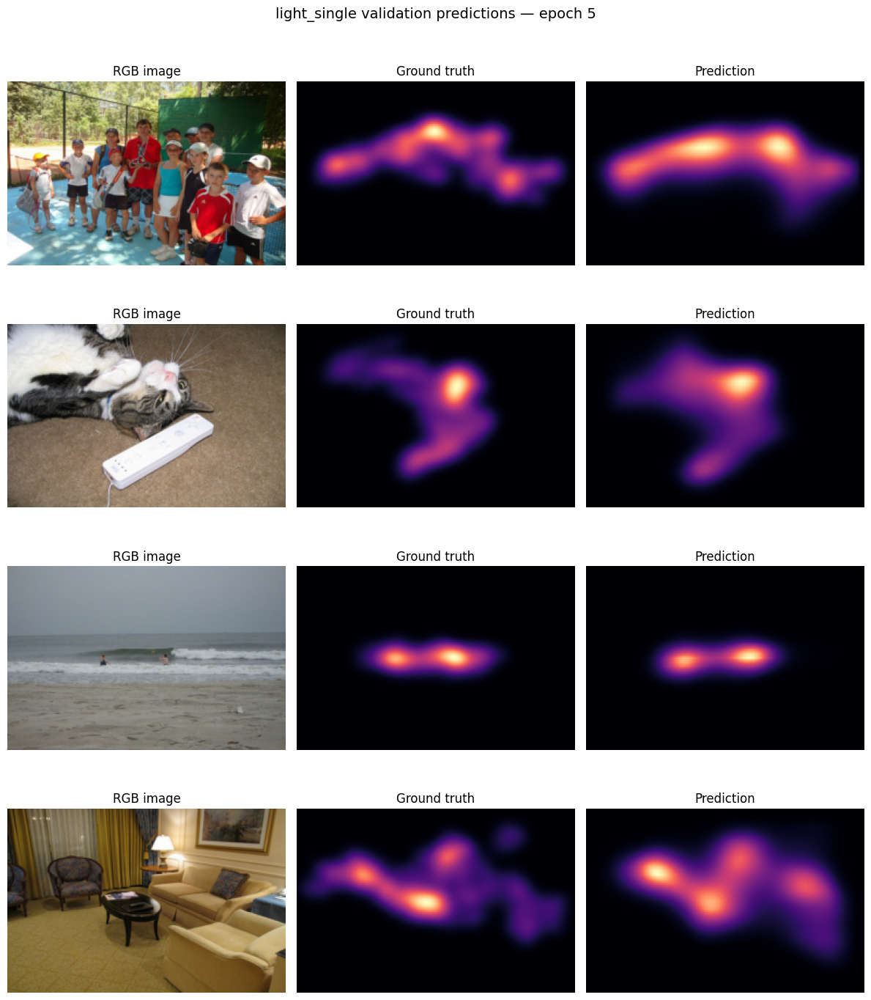


light_single | epoch 6/15 | encoder: trainable | AMP: True
Train loss: 0.2419 | Val loss: 0.3075 | Val KLD: 0.2427 | Val CC: 0.8716 | Val SIM: 0.7684
Epoch time: 2.40 min | Best val CC: 0.8739 | No-improvement counter: 1/3
Last checkpoint saved to: /content/drive/MyDrive/saliency_project/checkpoints/light_single/last.pt
History CSV updated at: /content/drive/MyDrive/saliency_project/outputs/metrics/light_single_history.csv


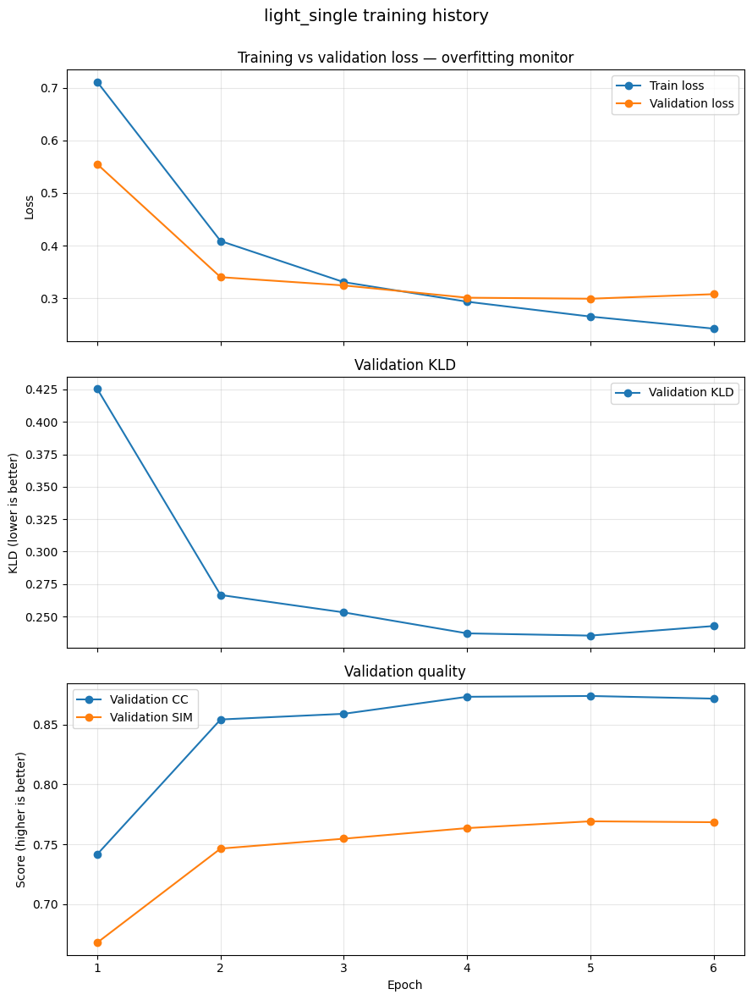

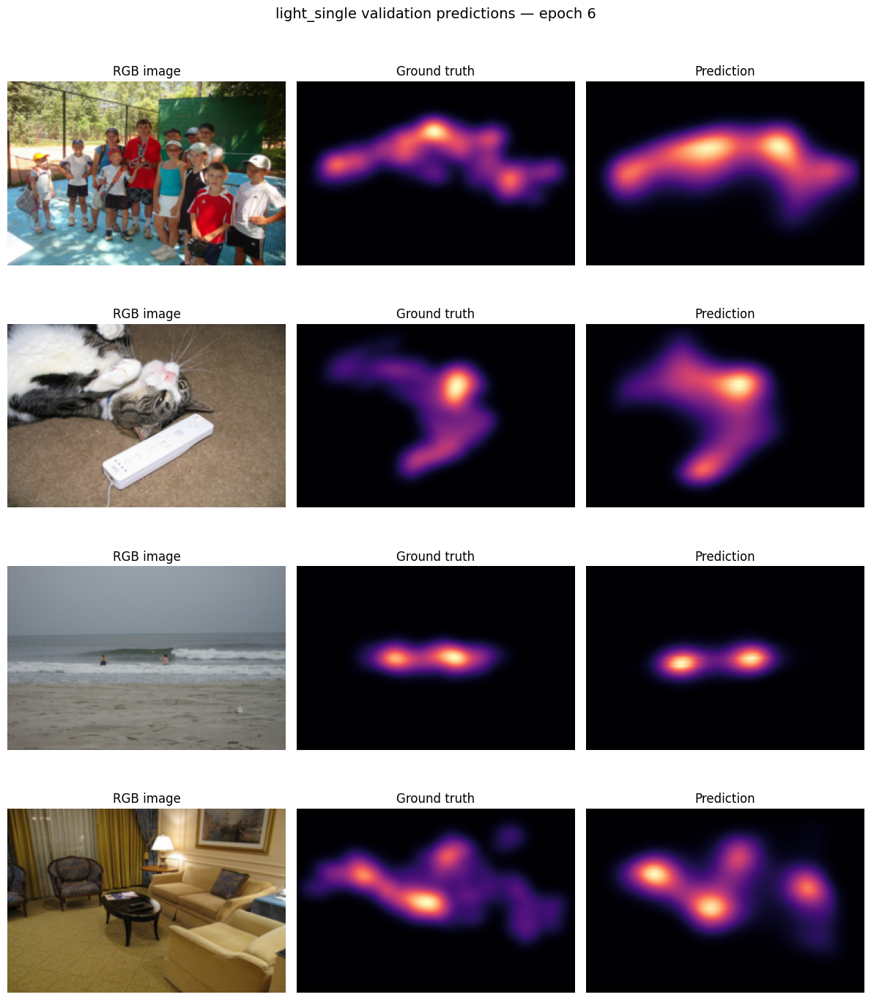


light_single | epoch 7/15 | encoder: trainable | AMP: True
Train loss: 0.2214 | Val loss: 0.3060 | Val KLD: 0.2422 | Val CC: 0.8738 | Val SIM: 0.7701
Epoch time: 2.40 min | Best val CC: 0.8739 | No-improvement counter: 2/3
Last checkpoint saved to: /content/drive/MyDrive/saliency_project/checkpoints/light_single/last.pt
History CSV updated at: /content/drive/MyDrive/saliency_project/outputs/metrics/light_single_history.csv


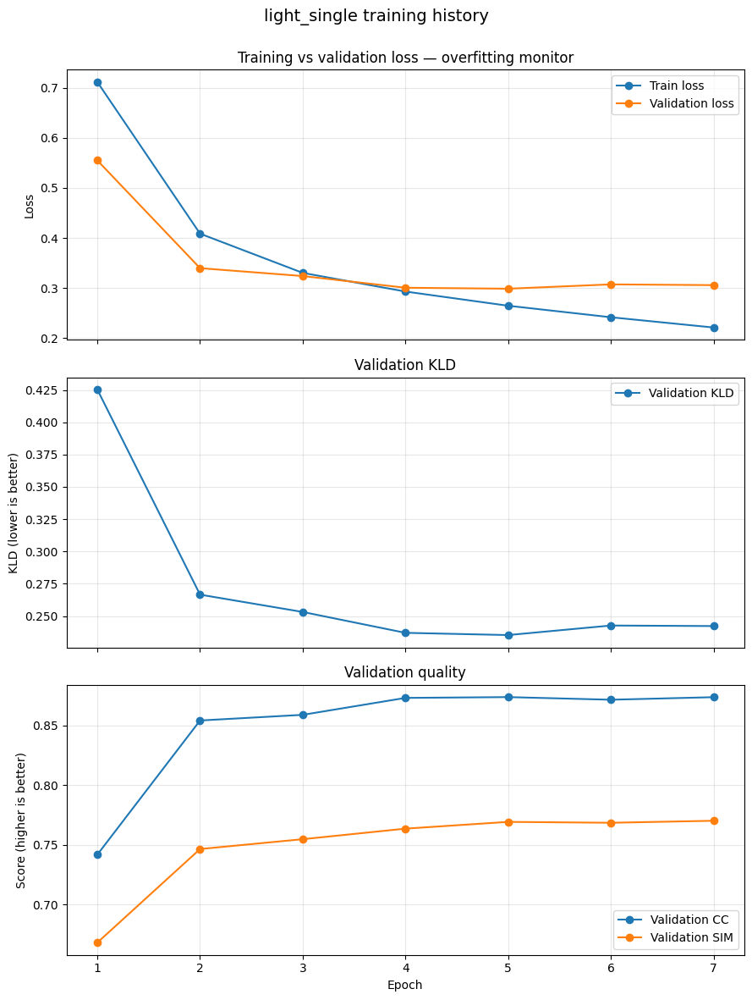

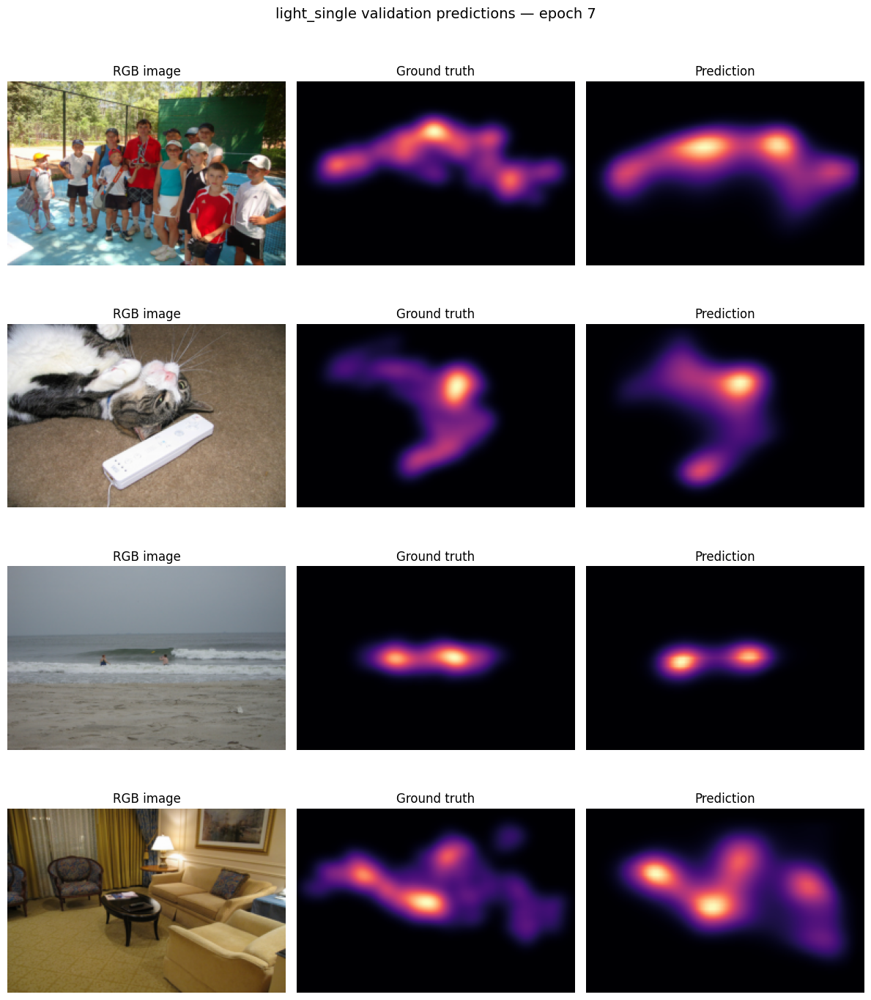


light_single | epoch 8/15 | encoder: trainable | AMP: True
Train loss: 0.2026 | Val loss: 0.3178 | Val KLD: 0.2519 | Val CC: 0.8696 | Val SIM: 0.7657
Epoch time: 2.41 min | Best val CC: 0.8739 | No-improvement counter: 3/3
Last checkpoint saved to: /content/drive/MyDrive/saliency_project/checkpoints/light_single/last.pt
History CSV updated at: /content/drive/MyDrive/saliency_project/outputs/metrics/light_single_history.csv


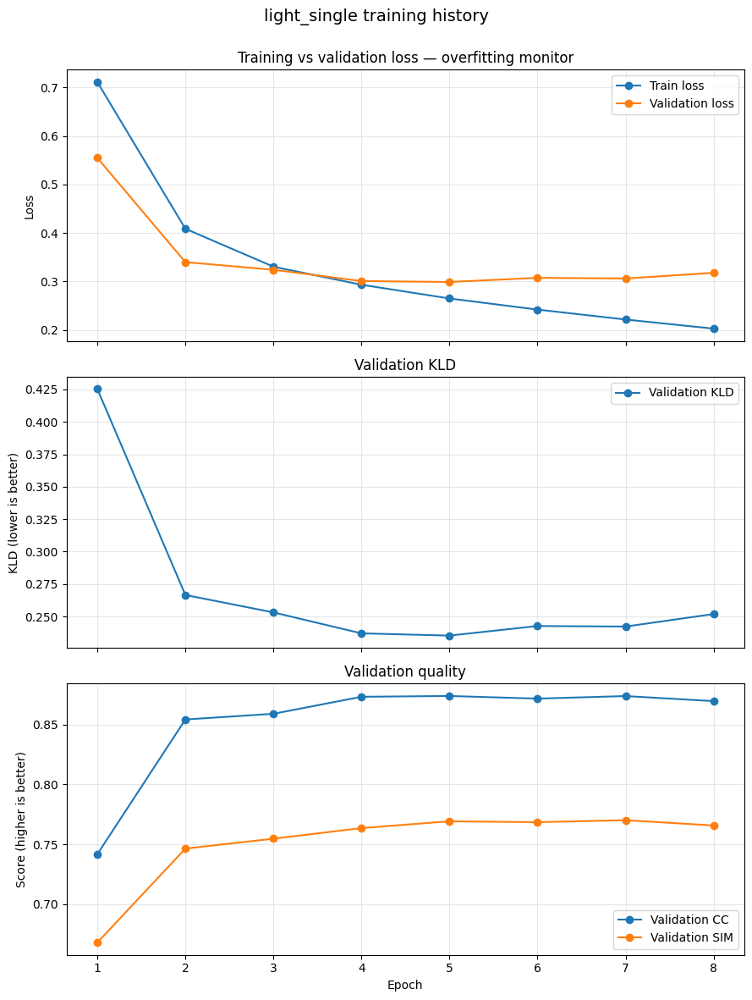

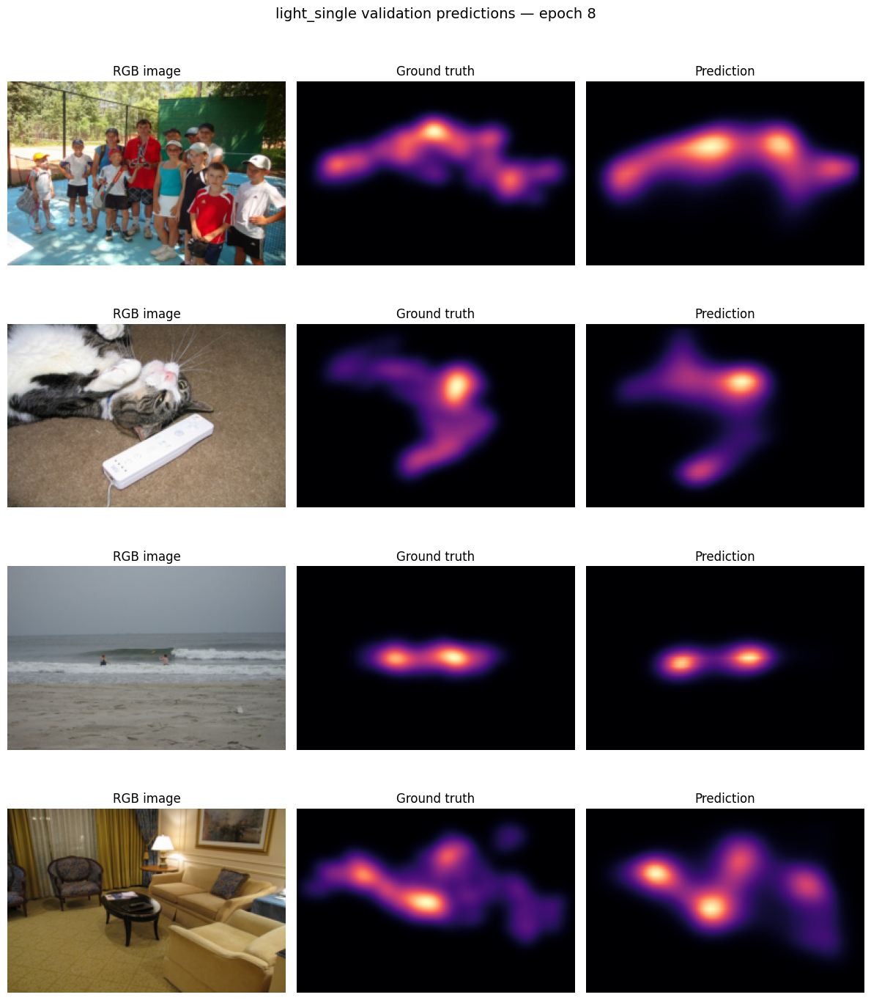

Early stopping: validation CC did not improve by at least 0.0001 for 3 consecutive epochs.

Training finished for light_single. Best validation CC: 0.8739. Elapsed time: 12.44 minutes.
Best checkpoint: /content/drive/MyDrive/saliency_project/checkpoints/light_single/best.pt
Last checkpoint: /content/drive/MyDrive/saliency_project/checkpoints/light_single/last.pt


,epoch,train_loss,val_loss,val_kld,val_cc,val_sim,encoder_trainable,epoch_time_seconds
0,1,0.711343,0.554842,0.425307,0.741707,0.667906,False,152.115096
1,2,0.408649,0.339826,0.266556,0.854228,0.746400,True,146.103652
2,3,0.330408,0.324076,0.253146,0.858973,0.754656,True,141.503598
3,4,0.293153,0.300759,0.236991,0.873181,0.763506,True,144.963449
4,5,0.264826,0.298817,0.235269,0.873851,0.769182,True,144.423681
5,6,0.241866,0.307463,0.242651,0.871643,0.768434,True,143.726084
6,7,0.221392,0.305971,0.242237,0.873786,0.770122,True,144.003034
7,8,0.202608,0.317770,0.251876,0.869552,0.765680,True,144.367355


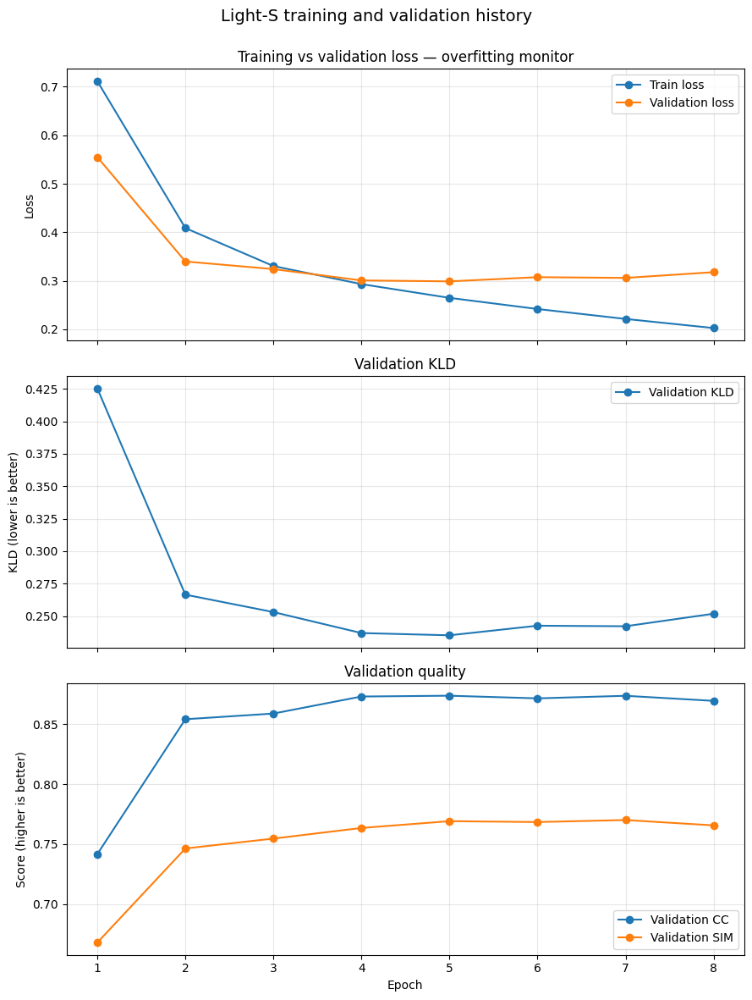

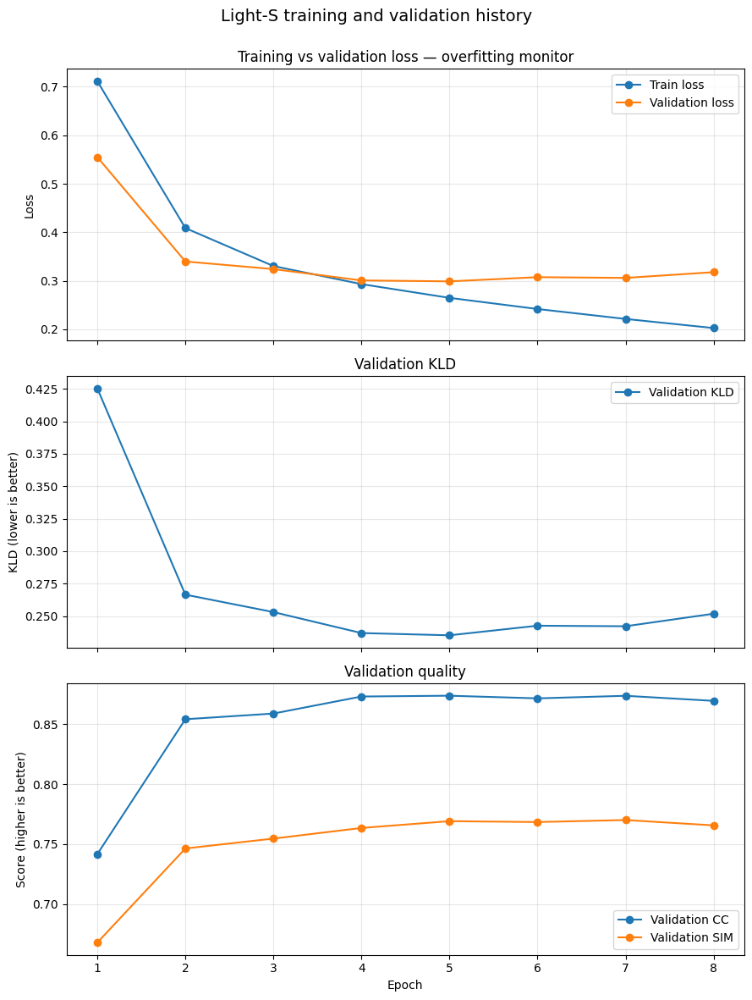

In [9]:
if not LAST_CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(
        "The pilot did not create last.pt. Inspect the pilot output before "
        "starting final training."
    )

light_single_model, light_single_optimizer = create_light_single_experiment()

final_history = fit_model(
    model=light_single_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=light_single_optimizer,
    device=DEVICE,

    model_name=MODEL_NAME,
    epochs=MAX_EPOCHS,

    checkpoint_dir=LIGHT_SINGLE_CHECKPOINT_DIR,
    history_csv_path=LIGHT_SINGLE_HISTORY_PATH,
    curves_figure_path=LIGHT_SINGLE_CURVES_PATH,

    preview_batch=preview_batch,
    preview_figure_path=LIGHT_SINGLE_PREVIEW_PATH,

    config=light_single_config,
    split_seed=SEED,
    repo_root=REPO_ROOT,

    patience=EARLY_STOPPING_PATIENCE,
    min_delta=1e-4,

    freeze_encoder_epochs=1,
    freeze_encoder_batchnorm=True,

    use_amp=True,
    gradient_clip_norm=GRADIENT_CLIP_NORM,

    resume_from=LAST_CHECKPOINT_PATH,
    show_curves_each_epoch=True,
)

final_history_frame = pd.DataFrame(final_history)

display(
    final_history_frame[
        [
            "epoch",
            "train_loss",
            "val_loss",
            "val_kld",
            "val_cc",
            "val_sim",
            "encoder_trainable",
            "epoch_time_seconds",
        ]
    ]
)

plot_training_history(
    final_history,
    output_path=LIGHT_SINGLE_CURVES_PATH,
    show=True,
    title="Light-S training and validation history",
)

## 10. Load and evaluate the best validation checkpoint

`best.pt` is selected by the highest validation CC. This final validation pass saves:

- one summary row;
- one row per validation image;
- the final training curves.

The test split remains untouched.

In [10]:
if not BEST_CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(
        "best.pt was not produced. Inspect the training output."
    )

best_checkpoint = load_checkpoint(
    BEST_CHECKPOINT_PATH,
    model=light_single_model,
    device=DEVICE,
)

validation_summary, validation_per_image = evaluate_and_save(
    model=light_single_model,
    dataloader=val_loader,
    device=DEVICE,
    model_name=MODEL_NAME,
    summary_csv_path=LIGHT_SINGLE_VAL_SUMMARY_PATH,
    per_image_csv_path=LIGHT_SINGLE_VAL_PER_IMAGE_PATH,
    use_amp=True,
)

print("Best epoch:         ", best_checkpoint["epoch"])
print("Best validation CC: ", best_checkpoint["best_val_cc"])
print("\nRecomputed validation metrics:")

display(pd.DataFrame([validation_summary]))

Best epoch:          5
Best validation CC:  0.8738509609222412

Recomputed validation metrics:


,model,loss,kld,cc,sim,num_samples,duration_seconds
0,light_single,0.298817,0.235269,0.873851,0.769182,2500,28.055321


## 11. Final artifact checklist

In [11]:
required_outputs = {
    "best checkpoint": BEST_CHECKPOINT_PATH,
    "last checkpoint": LAST_CHECKPOINT_PATH,
    "epoch history": LIGHT_SINGLE_HISTORY_PATH,
    "training curves": LIGHT_SINGLE_CURVES_PATH,
    "validation preview": LIGHT_SINGLE_PREVIEW_PATH,
    "validation summary": LIGHT_SINGLE_VAL_SUMMARY_PATH,
    "validation per-image metrics": LIGHT_SINGLE_VAL_PER_IMAGE_PATH,
}

all_outputs_exist = True

for label, path in required_outputs.items():
    exists = path.is_file()
    all_outputs_exist = all_outputs_exist and exists
    print(f"{label:30s} | {'OK' if exists else 'MISSING'} | {path}")

if not all_outputs_exist:
    raise RuntimeError(
        "One or more final Light-S artifacts are missing."
    )

print("\nLight-S training stage completed successfully.")
print("The next notebook is 04_light_multi.ipynb.")

best checkpoint                | OK | /content/drive/MyDrive/saliency_project/checkpoints/light_single/best.pt
last checkpoint                | OK | /content/drive/MyDrive/saliency_project/checkpoints/light_single/last.pt
epoch history                  | OK | /content/drive/MyDrive/saliency_project/outputs/metrics/light_single_history.csv
training curves                | OK | /content/drive/MyDrive/saliency_project/outputs/figures/training_curves_light_single.png
validation preview             | OK | /content/drive/MyDrive/saliency_project/outputs/figures/light_single_validation_predictions.png
validation summary             | OK | /content/drive/MyDrive/saliency_project/outputs/metrics/light_single_validation_metrics.csv
validation per-image metrics   | OK | /content/drive/MyDrive/saliency_project/outputs/metrics/light_single_validation_per_image.csv

Light-S training stage completed successfully.
The next notebook is 04_light_multi.ipynb.


## Next project stage

Create `04_light_multi.ipynb` and reuse the same local cache, manifests, training functions, loss, optimizer policy, checkpoint rule, and plots.

The Light-M notebook must first verify multi-scale fusion, then run:

```text
sanity check
→ three-epoch pilot
→ final training
→ best-checkpoint validation
```

The controlled comparison between Light-S and Light-M isolates the value and cost of multi-scale feature fusion under the same MobileNetV2 encoder.